In [23]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [24]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\_nonaromatic_2025_765_CHOP.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
341,"Phosphine, diisopropylhydroxy-",C6H15OP,134,53753-58-5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)P(O)C(C)C,CHOP
768,"Phosphine, acetyldimethyl-",C4H9OP,104,18983-86-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CP(C)C(C)=O,CHOP
1229,"1,3-Dioxolane, 2,2-dimethyl-4-phosphinomethyl-",C6H13O2P,148,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC1(C)OCC(CP)O1,CHOP
1317,"Phosphine, acetylbis(1-methylethyl)-",C8H17OP,160,50837-80-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)P(C(C)C)C(C)=O,CHOP
1496,"1,2-Oxaphospholan-3-ol, 2-ethoxy-3,5,5-trimeth...",C8H17O4P,208,39770-54-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCO[P]1(=O)OC(C)(C)CC1(C)O,CHOP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181145,"Phosphonic acid, (3-methyl-2-oxo-3-pentenyl)-,...",C8H15O4P,206,54543-04-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CO[P](=O)(CC(=O)C(/C)=C/C)OC,CHOP
181163,"Phosphoric acid, ethenyl dimethyl ester",C4H9O4P,152,10429-10-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CO[P](=O)(OC)OC=C,CHOP
181237,"Phosphoric acid, diethyl 1-propenyl ester",C7H15O4P,194,34600-14-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCO[P](=O)(OCC)OC=CC,CHOP
181927,"Butanoic acid, 2-(diethoxyphosphinyl)-, ethyl ...",C10H21O5P,252,17145-91-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)C(CC)[P](=O)(OCC)OCC,CHOP


In [ ]:
# Create DEEPCHEM dataset
# First check if there are SMILES with a dot '.'
# These cannot be FEATURIZED and must be removed from the dataset.
X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
se = []
dr = [] # all these compounds should be removed
c=0
for i in y:
  se.append(sf.encoder(i))  # contains all SELFIES
  if '.' in sf.encoder(i):  # check if there is a dot in the selfies
    dr.append(c)
  c=c+1
# remove compounds which will give an error when featurizing
a=0
for i in dr:
  ms = ms.drop([ms.index[i-a]])
  a=a+1
# create new DeepChem dataset
X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
ds = dc.data.DiskDataset.from_numpy(X,y)
ds

<DiskDataset X.shape: (np.int64(765), np.int64(600)), y.shape: (np.int64(765),), w.shape: (np.int64(765),), ids: [0 1 2 ... 762 763 764], task_names: [0]>

In [26]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[/C]': 3,
 '[=Branch1]': 4,
 '[=Branch2]': 5,
 '[=CH0]': 6,
 '[=C]': 7,
 '[=N]': 8,
 '[=O]': 9,
 '[=PH0]': 10,
 '[=PH1]': 11,
 '[Branch1]': 12,
 '[Branch2]': 13,
 '[CH1]': 14,
 '[C]': 15,
 '[N]': 16,
 '[O]': 17,
 '[PH0]': 18,
 '[PH1]': 19,
 '[PH2]': 20,
 '[P]': 21,
 '[Ring1]': 22,
 '[Ring2]': 23,
 '[S]': 24,
 '[\\C]': 25,
 '[nop]': 26}

In [27]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

----------------------------

In [45]:
import deepchem as dc

seed = 42  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.8,
    frac_valid=0,
    frac_test=0.2,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 42
📦 Training set size: 598
📦 Validation set size: 0
📦 Test set size: 167


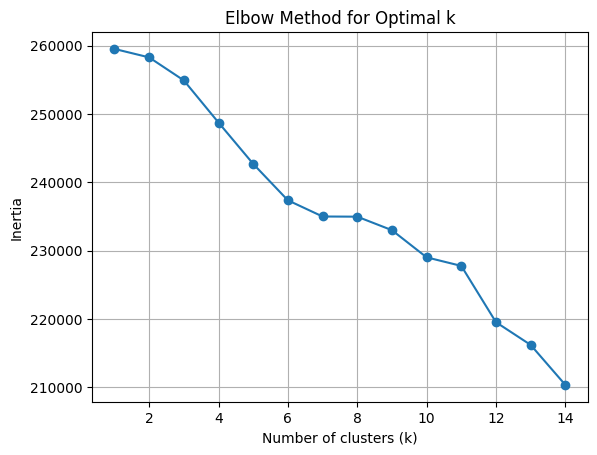

🔍 Elbow point detected at k = 1


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [47]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=2,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

In [48]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(2):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (394, 600)
Cluster 1 shape: (204, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

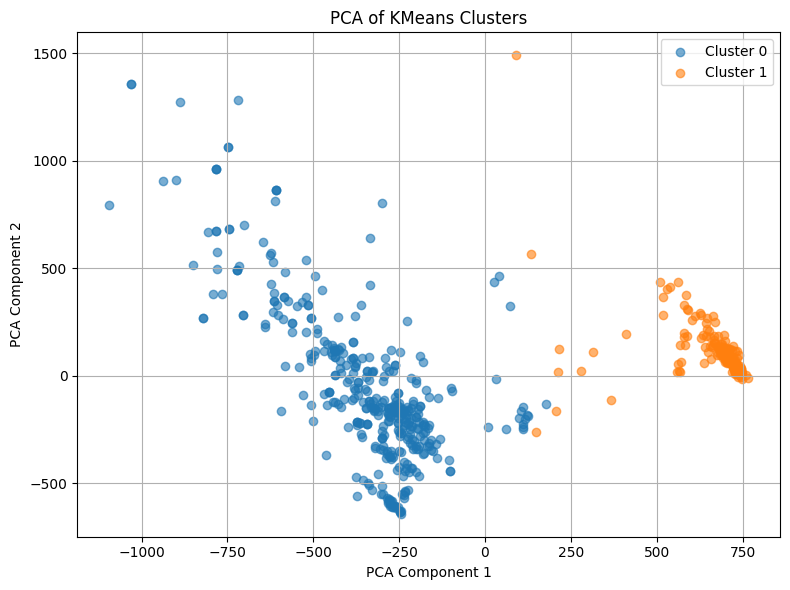

In [49]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [50]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [ ]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")

✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_

Cluster 0: size = 105, shape = (105, 600)
Cluster 1: size = 62, shape = (62, 600)


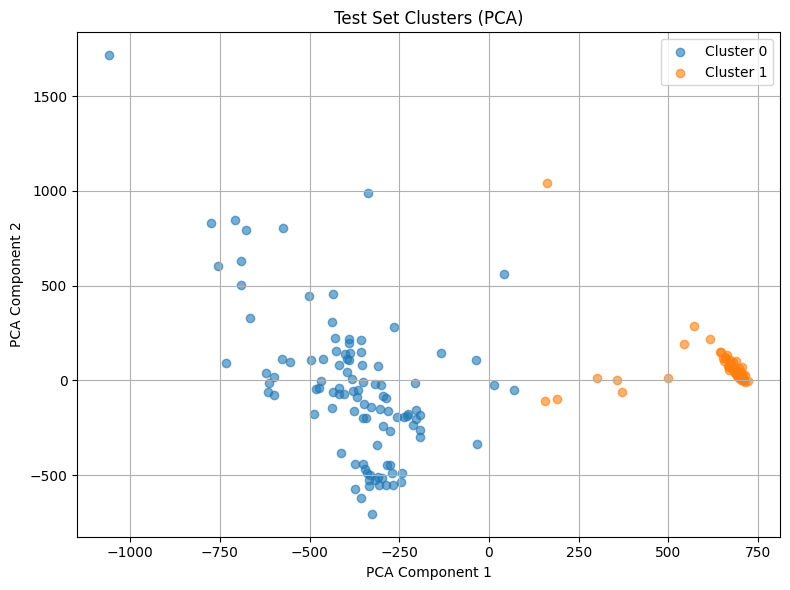

In [52]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(2):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/175 - Loss: 0.690291
Epoch 2/175 - Loss: 0.075517
Epoch 3/175 - Loss: 0.051751
Epoch 4/175 - Loss: 0.045711
Epoch 5/175 - Loss: 0.042830
Epoch 6/175 - Loss: 0.039981
Epoch 7/175 - Loss: 0.037402
Epoch 8/175 - Loss: 0.035119
Epoch 9/175 - Loss: 0.032967
Epoch 10/175 - Loss: 0.030978
Epoch 11/175 - Loss: 0.029416
Epoch 12/175 - Loss: 0.027618
Epoch 13/175 - Loss: 0.026368
Epoch 14/175 - Loss: 0.024819
Epoch 15/175 - Loss: 0.023434
Epoch 16/175 - Loss: 0.022133
Epoch 17/175 - Loss: 0.021028
Epoch 18/175 - Loss: 0.019841
Epoch 19/175 - Loss: 0.018683
Epoch 20/175 - Loss: 0.017769
Epoch 21/175 - Loss: 0.016729
Epoch 22/175 - Loss: 0.015776
Epoch 23/175 - Loss: 0.015037
Epoch 24/175 - Loss: 0.014143
Epoch 25/175 - Loss: 0.013284
Epoch 26/175 - Loss: 0.012469
Epoch 27/175 - Loss: 0.011786
Epoch 28/175 - Loss: 0.011168
Epoch 29/175 - Loss: 0.010342
Epoch 30/175 - Loss: 0.009831
Epoch 31/175 - Loss: 0.009433
Epoch 32/175 - Loss: 0.009004
Epoch 33/175 - Loss: 0.008856
Epoch 34/175 - Loss

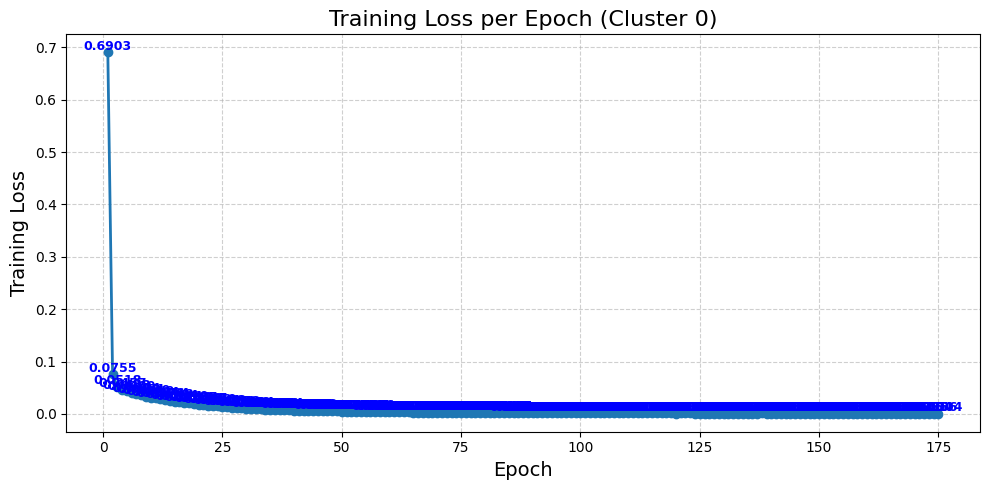

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\models_\model0000


In [53]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 175

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [54]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [55]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (105, 1782, 2)
Example prediction: [[1.0000000e+00 2.5306977e-12]
 [1.0000000e+00 4.8128460e-16]
 [1.0000000e+00 1.2127566e-11]
 ...
 [1.0000000e+00 1.3726581e-16]
 [1.0000000e+00 4.0402881e-16]
 [6.3817007e-13 1.0000000e+00]]


In [56]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [58]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [59]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CC(C)P(O)C(C)C | True: CC(C)P(O)C(C)C | Tanimoto: 1.000
[1] Pred: CCOP1OCC(C)(C)CO1 | True: CCOP1OCC(C)(C)CO1 | Tanimoto: 1.000
[2] Pred: CO[PH0](=O)(CC(=O)C(/C)=C/C)OC | True: CO[PH0](=O)(CC(=O)C(/C)=C/C)OC | Tanimoto: 1.000
[3] Pred: C1COOCCC1O | True: CC1OP(C)OC1C | Tanimoto: 0.119
[4] Pred: CCOCCC(C)CC | True: CC1OP(OC1C)C(C)(C)C | Tanimoto: 0.076
[5] Pred: CCCO[PH0](=O)(C)OC(C)COCCCCCC | True: CC12CO[PH0](=O)(OC1)OC2 | Tanimoto: 0.212
[6] Pred: C1CCCOOPC1 | True: CC[PH0]1(=O)CC=C(C)O1 | Tanimoto: 0.080
[7] Pred: CC(CC=O)C(C)CCCCC | True: COC(=O)C=CP(C(C)C)C(C)C | Tanimoto: 0.052
[8] Pred: CCO[PH0]P(C)CCC | True: CCOP(C)OCC | Tanimoto: 0.132
[9] Pred: CCCCCC(C=O)COCCC | True: COCCOC(=O)C1OP(OC1C(=O)OCCOC)C(C)(C)C | Tanimoto: 0.104
[10] Pred: CCCC[PH0](C)=O | True: COCCO[PH0]1(=O)OCC(C)(C)CO1 | Tanimoto: 0.028
[11] Pred: CCCCOP(OCCCC)OCCCC | True: CCCCOP(OCCCC)OCCCC | Tanimoto: 1.000
[12] Pred: CC(C)COP(OCC(C)C)OCC(C)C | True: CC(C)COP(OCC(C)C)OCC(C)C | Tanimoto: 1.000
[13

Epoch 1/100 - Loss: 0.744506
Epoch 2/100 - Loss: 0.065342
Epoch 3/100 - Loss: 0.057684
Epoch 4/100 - Loss: 0.040195
Epoch 5/100 - Loss: 0.032661
Epoch 6/100 - Loss: 0.029003
Epoch 7/100 - Loss: 0.027391
Epoch 8/100 - Loss: 0.026101
Epoch 9/100 - Loss: 0.024835
Epoch 10/100 - Loss: 0.023931
Epoch 11/100 - Loss: 0.023124
Epoch 12/100 - Loss: 0.022229
Epoch 13/100 - Loss: 0.021620
Epoch 14/100 - Loss: 0.020602
Epoch 15/100 - Loss: 0.019862
Epoch 16/100 - Loss: 0.019081
Epoch 17/100 - Loss: 0.018355
Epoch 18/100 - Loss: 0.017656
Epoch 19/100 - Loss: 0.016741
Epoch 20/100 - Loss: 0.015852
Epoch 21/100 - Loss: 0.015144
Epoch 22/100 - Loss: 0.014173
Epoch 23/100 - Loss: 0.013510
Epoch 24/100 - Loss: 0.012851
Epoch 25/100 - Loss: 0.012402
Epoch 26/100 - Loss: 0.011757
Epoch 27/100 - Loss: 0.012031
Epoch 28/100 - Loss: 0.012886
Epoch 29/100 - Loss: 0.011675
Epoch 30/100 - Loss: 0.009748
Epoch 31/100 - Loss: 0.009696
Epoch 32/100 - Loss: 0.008746
Epoch 33/100 - Loss: 0.008218
Epoch 34/100 - Loss

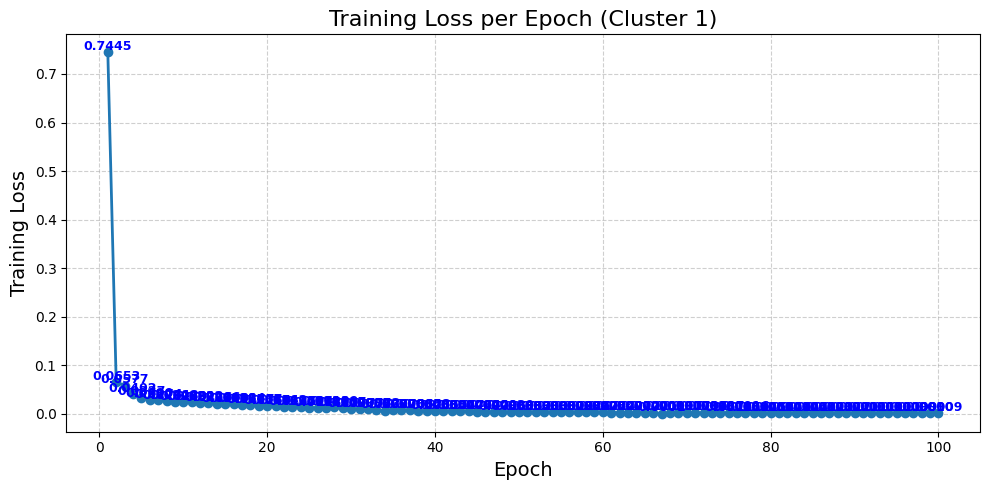

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with seed 123\models_\model1111


In [43]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [44]:


import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_765_CHOP\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (59, 1782, 2)
Example prediction: [[1.0000000e+00 4.4579055e-29]
 [1.0000000e+00 5.5726349e-24]
 [1.0000000e+00 1.0508589e-27]
 ...
 [1.0000000e+00 1.3034726e-26]
 [1.0000000e+00 3.4324535e-32]
 [6.5784972e-26 1.0000000e+00]]
[0] Pred: CCCC[PH0](=O)(OCC)OC(C)C#C | True: CCCC[PH0](=O)(OC(C)C#C)OC(C)C#C | Tanimoto: 1.000
[1] Pred: CCCCCCCCCCCCCCC(CCCC)CCCCCCCCC | True: CCCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCC(C)CCOC | Tanimoto: 0.072
[2] Pred: CCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCCCCCCCCCOC | True: CCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCC(CCCC)CCOC | Tanimoto: 0.765
[3] Pred: CCCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCCCCCCCCC | True: CCCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCC(CCCC)CCOC | Tanimoto: 0.735
[4] Pred: CCCCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCCCCCCCCC | True: CCCCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCC(CCCC)CCOC | Tanimoto: 0.735
[5] Pred: CCCCCCCCCCCCCCCCCC[PH0](=O)(CCCC)OCCCCC | True: CCCCCCCCCCCCCCCCCCO[PH0](=O)(CCCC)OCC(C)(C)C | Tanimoto: 0.366
[6] Pred: CCCC[PH0](=O)(OCCC)OCC1(C)CCCC1 | True: CCCC[PH0